# Data Science Assignment: Credit Card Customer Analysis

In [1]:
!pip install scikit-learn==1.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 50.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.3.0 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.3.0 which is incompatible.


In [2]:
import warnings

warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Data Exploration and Preprocessing


### Data Understanding: Load the dataset and perform an initial exploration to understand its structure, identify missing values, and gather basic statistics.

In [3]:
data = pd.read_csv('BankChurners.csv')
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
data = data.drop(['CLIENTNUM','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1)

**Dropped Clientnum beacuse it is ID and dropped other two columns because it was written in dataset description on Kaggle**

In [6]:
data.shape

(10127, 20)

In [7]:
data.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

##### Summary statistics

In [9]:
data.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


### Preprocessing: Clean the dataset by handling missing values, outliers, and any erroneous data points. Document your decisions.

In [10]:
data.isna().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


No missing values found in the dataset

#### Outlier Detection and Removal using IQR method

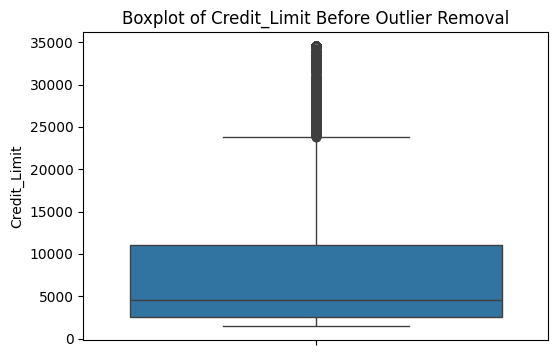

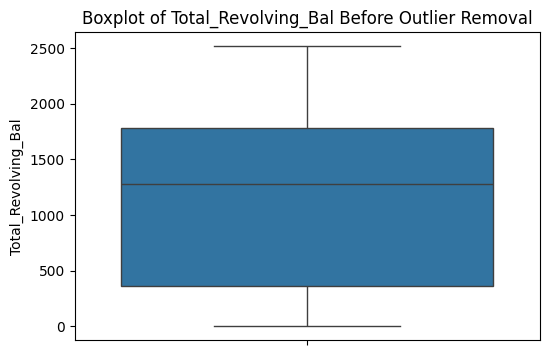

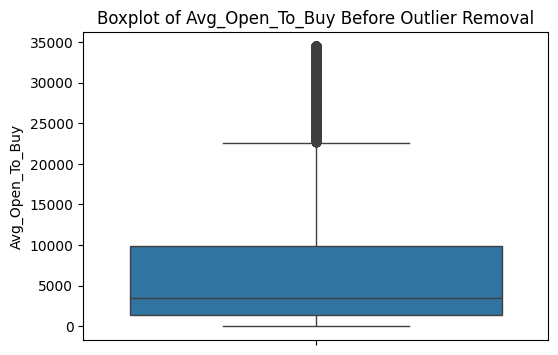

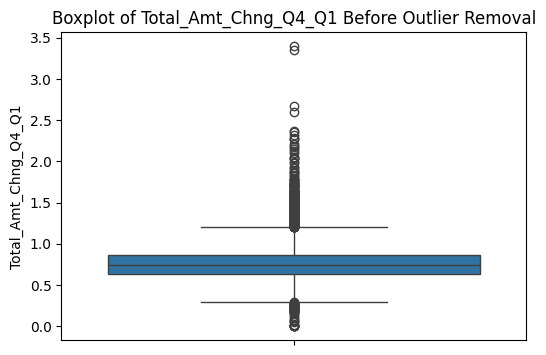

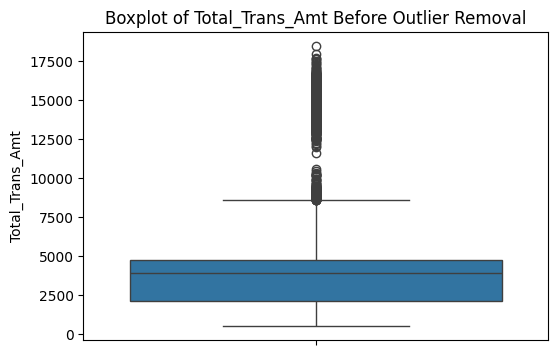

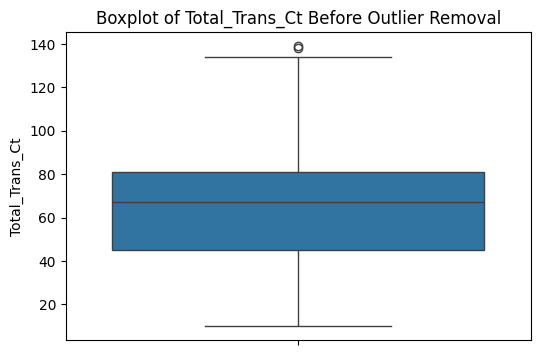

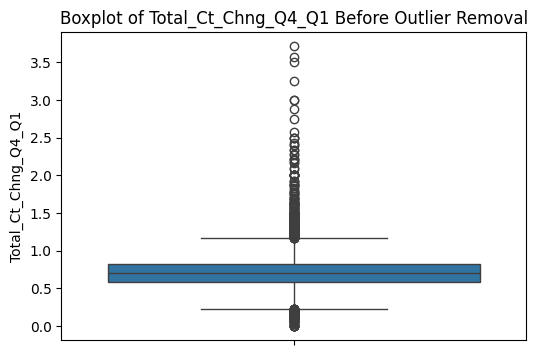

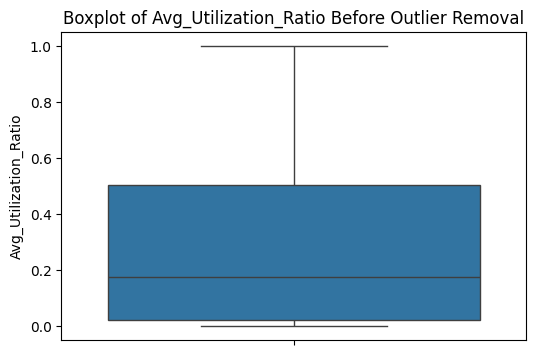

In [11]:
outlier_columns = [
    'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]
for col in outlier_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data[col])
    plt.title(f"Boxplot of {col} Before Outlier Removal")
    plt.show()

In [12]:
Q1 = data[outlier_columns].quantile(0.25)
Q3 = data[outlier_columns].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [13]:
data = data[~((data[outlier_columns] < lower_bound) | (data[outlier_columns] > upper_bound)).any(axis=1)]

#### Plots after outlier removal

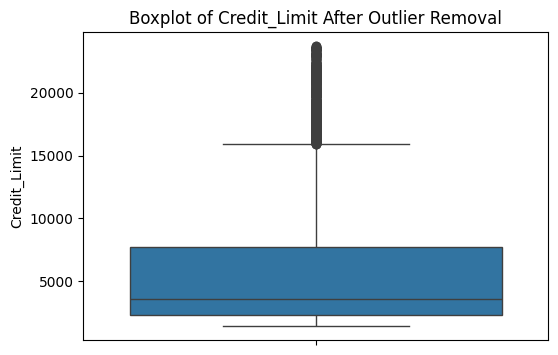

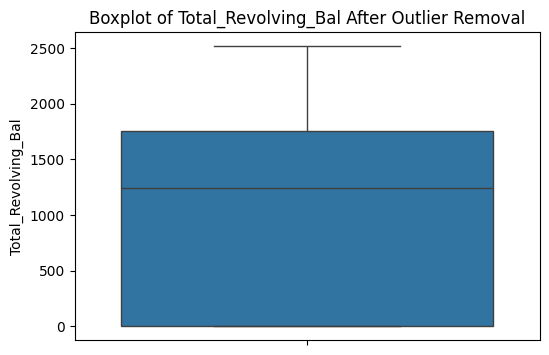

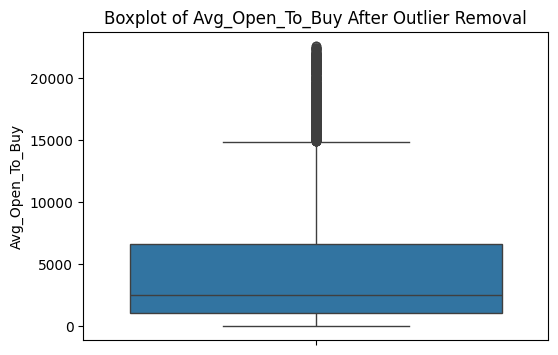

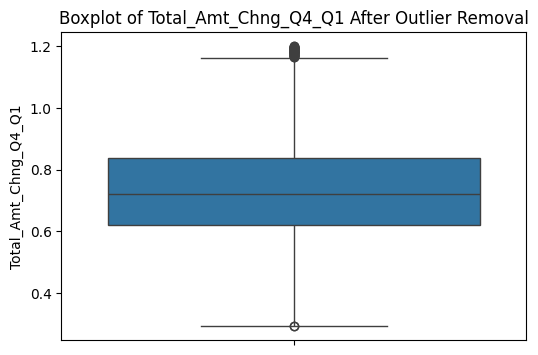

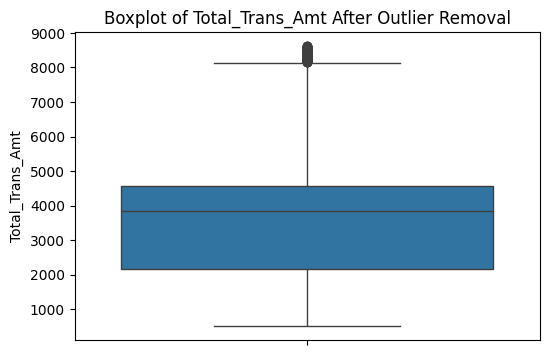

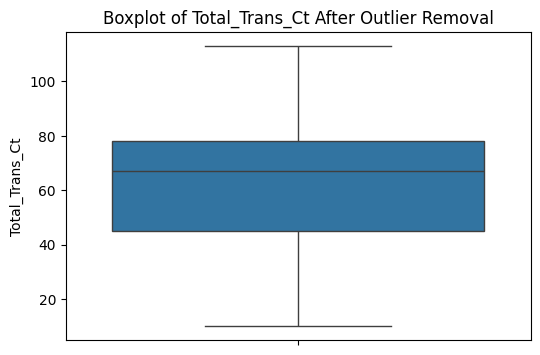

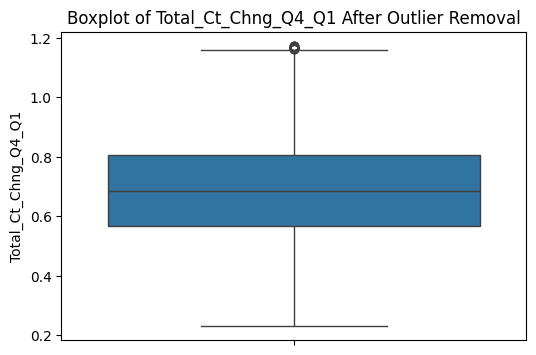

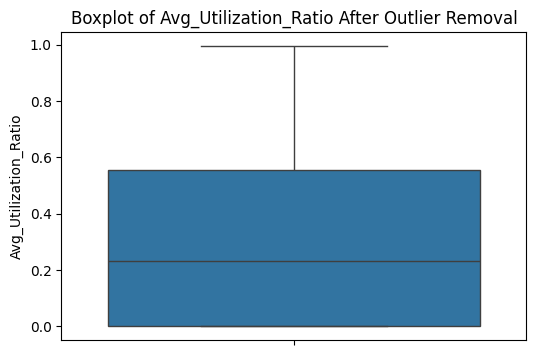

In [14]:
for col in outlier_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data[col])
    plt.title(f"Boxplot of {col} After Outlier Removal")
    plt.show()

'Credit_Limit' and 'Avg_Open_To_Buy' have high values which did not get removed during outlier removal.
Removing them could remove meaningful customer segments.

In [15]:
print("\nDataset after preprocessing:")
data.info()


Dataset after preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 10 to 10125
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            7814 non-null   object 
 1   Customer_Age              7814 non-null   int64  
 2   Gender                    7814 non-null   object 
 3   Dependent_count           7814 non-null   int64  
 4   Education_Level           7814 non-null   object 
 5   Marital_Status            7814 non-null   object 
 6   Income_Category           7814 non-null   object 
 7   Card_Category             7814 non-null   object 
 8   Months_on_book            7814 non-null   int64  
 9   Total_Relationship_Count  7814 non-null   int64  
 10  Months_Inactive_12_mon    7814 non-null   int64  
 11  Contacts_Count_12_mon     7814 non-null   int64  
 12  Credit_Limit              7814 non-null   float64
 13  Total_Revolving_Bal       7814 non-n

## Part 2: Data Analysis and Visualization

### Customer Demographics Analysis: Analyze the demographics of the credit card holders (e.g., age, salary, marital status) and visualize the distributions.

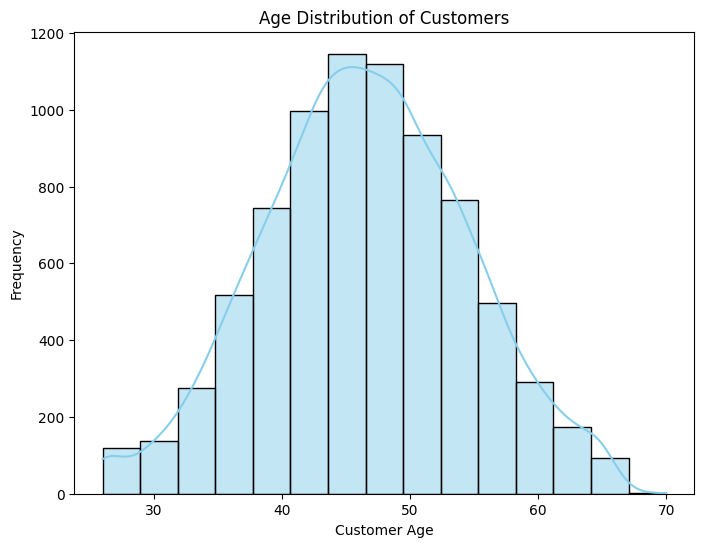

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(data['Customer_Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution of Customers')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.show()

The average customer age is in the mid-40s to early 50s, following a normal distribution.

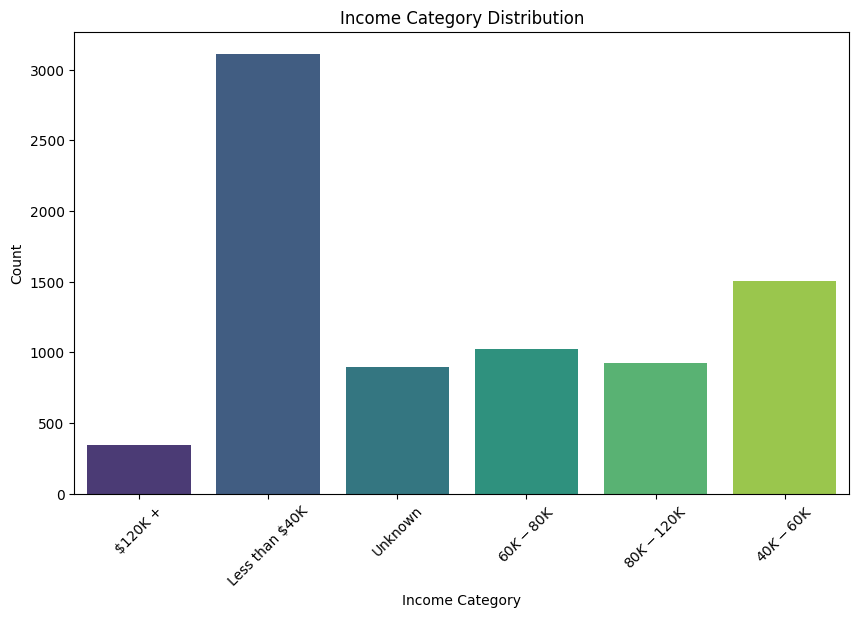

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Income_Category', data=data, palette='viridis')
plt.title('Income Category Distribution')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The most common income category is "Less than $40K".

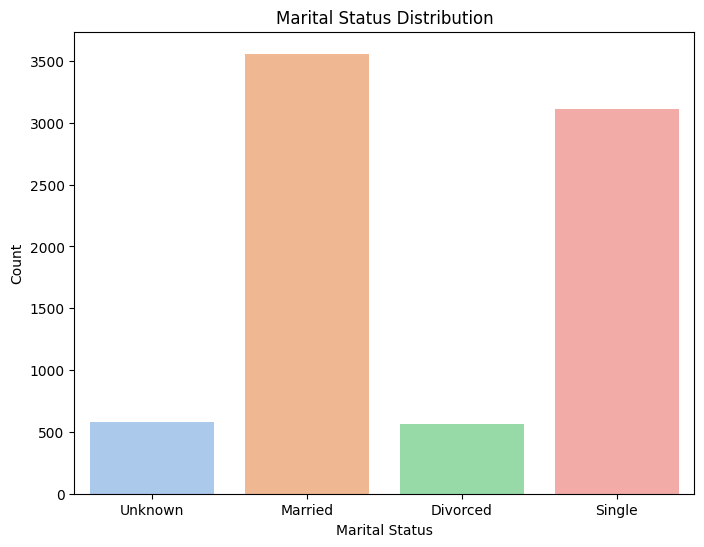

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Marital_Status', data=data, hue='Marital_Status', palette='pastel')
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

Most customers are either "Married" or "Single".
Divorced are also counted as Single

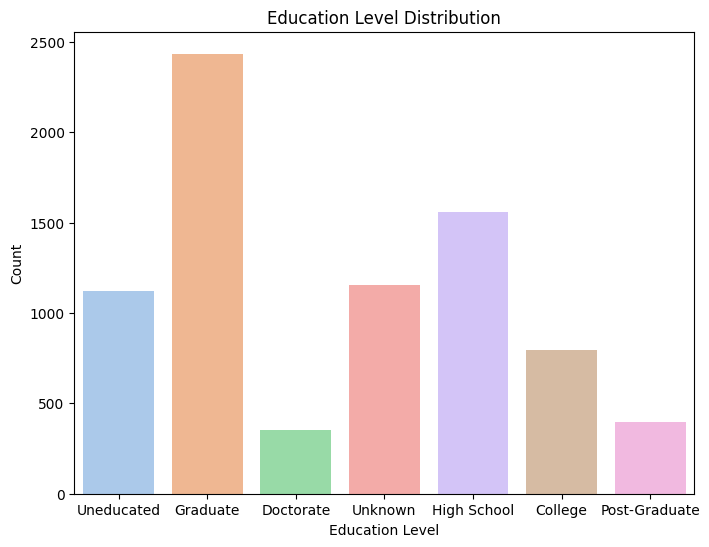

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Education_Level', data=data, palette='pastel')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

The most common education level is "Graduate".

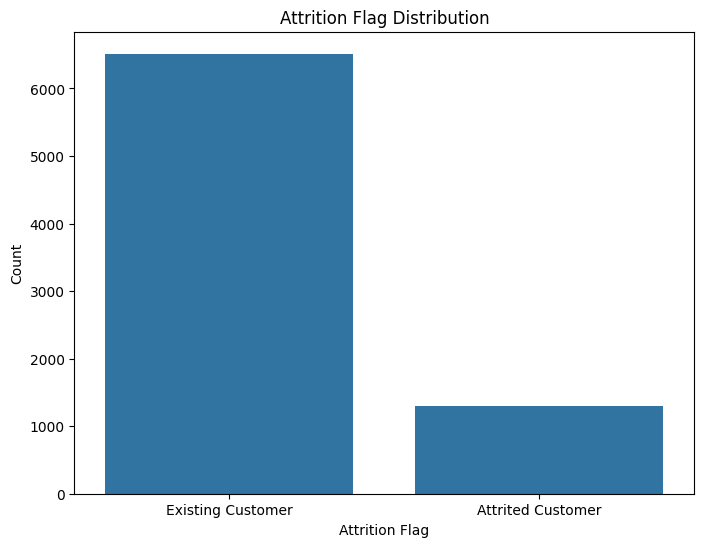

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Attrition_Flag', data=data)
plt.title('Attrition Flag Distribution')
plt.xlabel('Attrition Flag')
plt.ylabel('Count')
plt.show()

More Customers Existing than Attrited

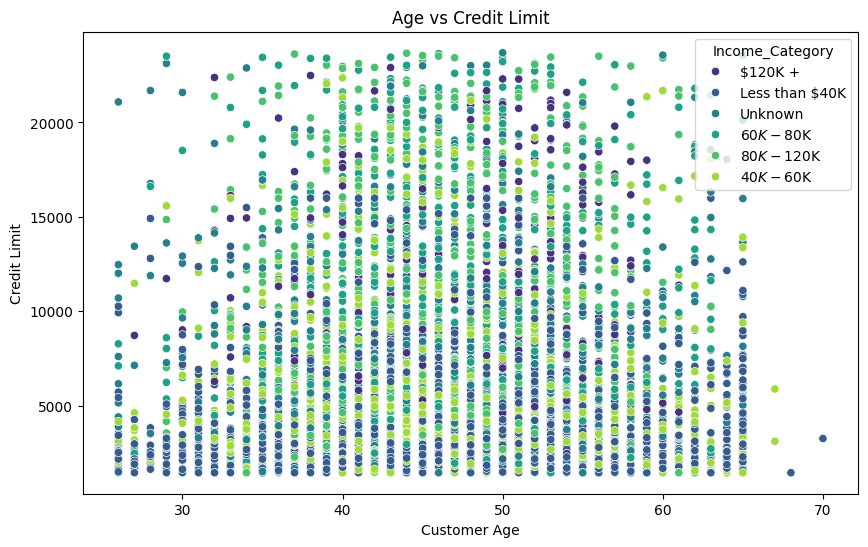

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Customer_Age', y='Credit_Limit', data=data, hue='Income_Category', palette='viridis')
plt.title('Age vs Credit Limit')
plt.xlabel('Customer Age')
plt.ylabel('Credit Limit')
plt.show()

There's a weak positive correlation between age and credit limit, meaning older customers tend to have slightly higher credit limits, but the relationship is noisy.
Income appears to be a stronger predictor of credit limit than age, with higher income categories generally having higher credit limits, but there's still considerable overlap.(Ignoring the unknown)

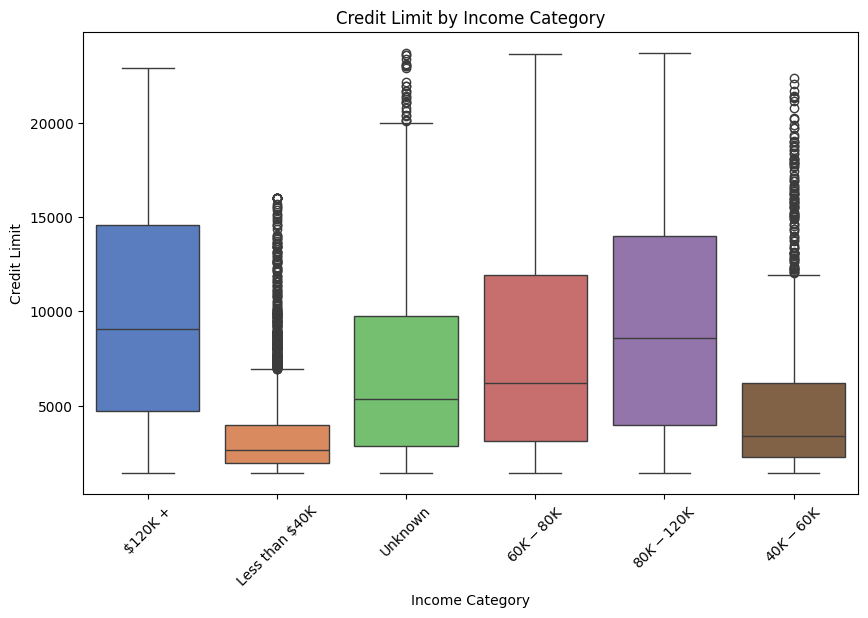

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Category', y='Credit_Limit', data=data, palette='muted')
plt.title('Credit Limit by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Credit Limit')
plt.xticks(rotation=45)
plt.show()

Higher income categories (from $60K to $120K+) correlate with higher median credit limits and greater variability in those limits.

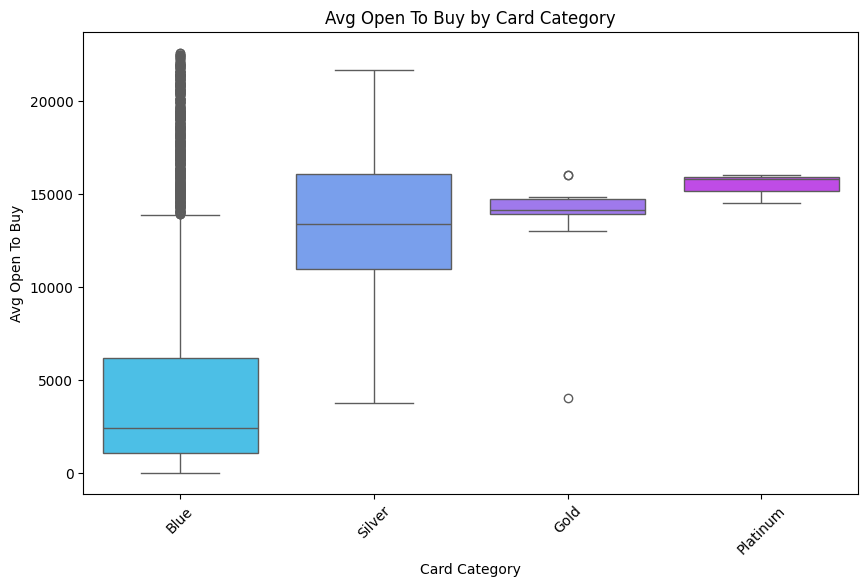

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Card_Category', y='Avg_Open_To_Buy', data=data, palette='cool')
plt.title('Avg Open To Buy by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Avg Open To Buy')
plt.xticks(rotation=45)
plt.show()

"Open to buy" amounts generally increase with card tier (Blue to Platinum), showing greater variability at higher tiers.

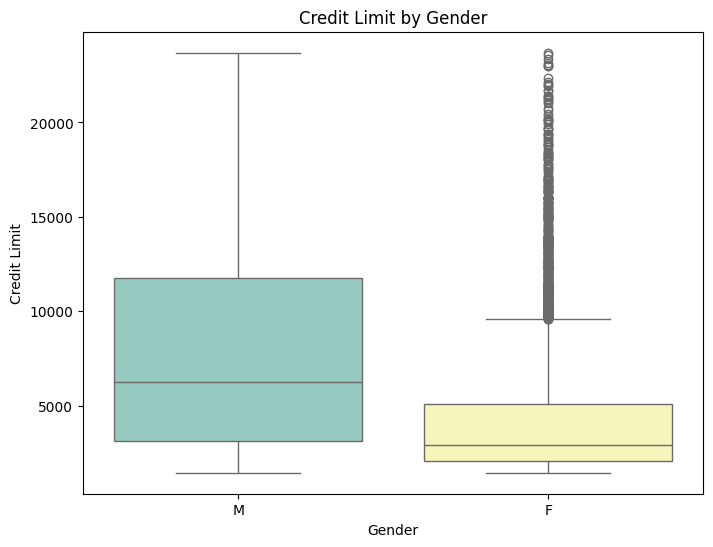

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Credit_Limit', data=data, palette='Set3')
plt.title('Credit Limit by Gender')
plt.xlabel('Gender')
plt.ylabel('Credit Limit')
plt.show()

Males showing more credit limit than females

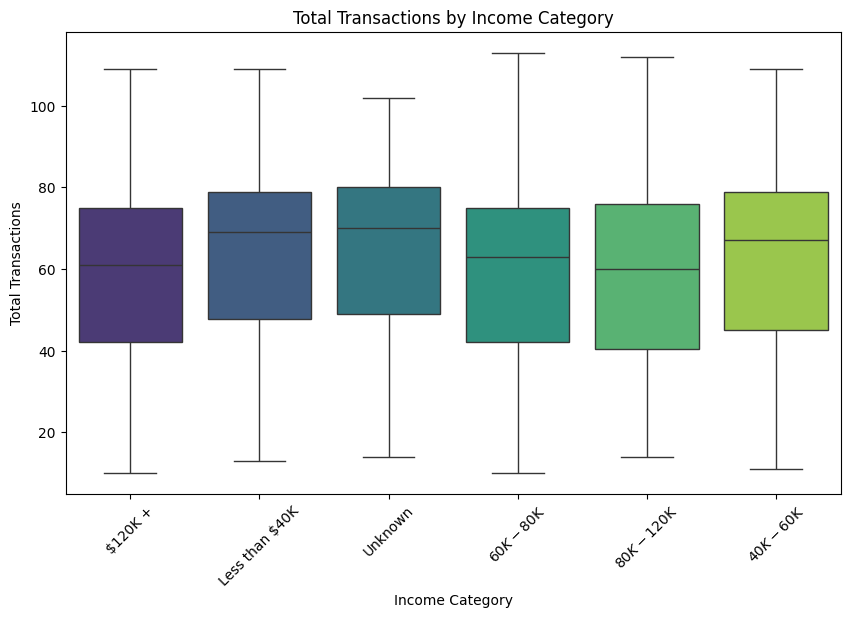

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Category', y='Total_Trans_Ct', data=data, palette='viridis')
plt.title('Total Transactions by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.show()


Transaction counts show less distinct variation across income categories compared to credit limits

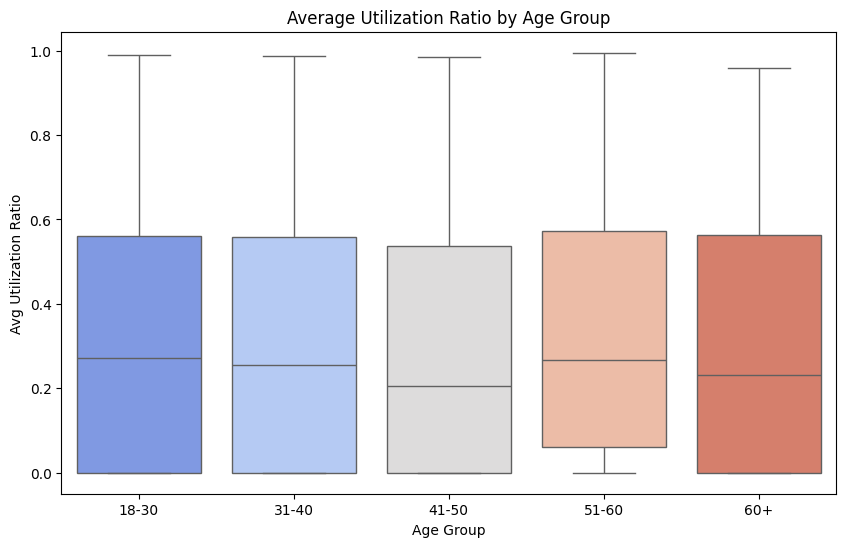

In [26]:
age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']
data['Age_Group'] = pd.cut(data['Customer_Age'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Group', y='Avg_Utilization_Ratio', data=data, palette='coolwarm')
plt.title('Average Utilization Ratio by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Utilization Ratio')
plt.show()

Utilization ratio shows minimal variation across age group

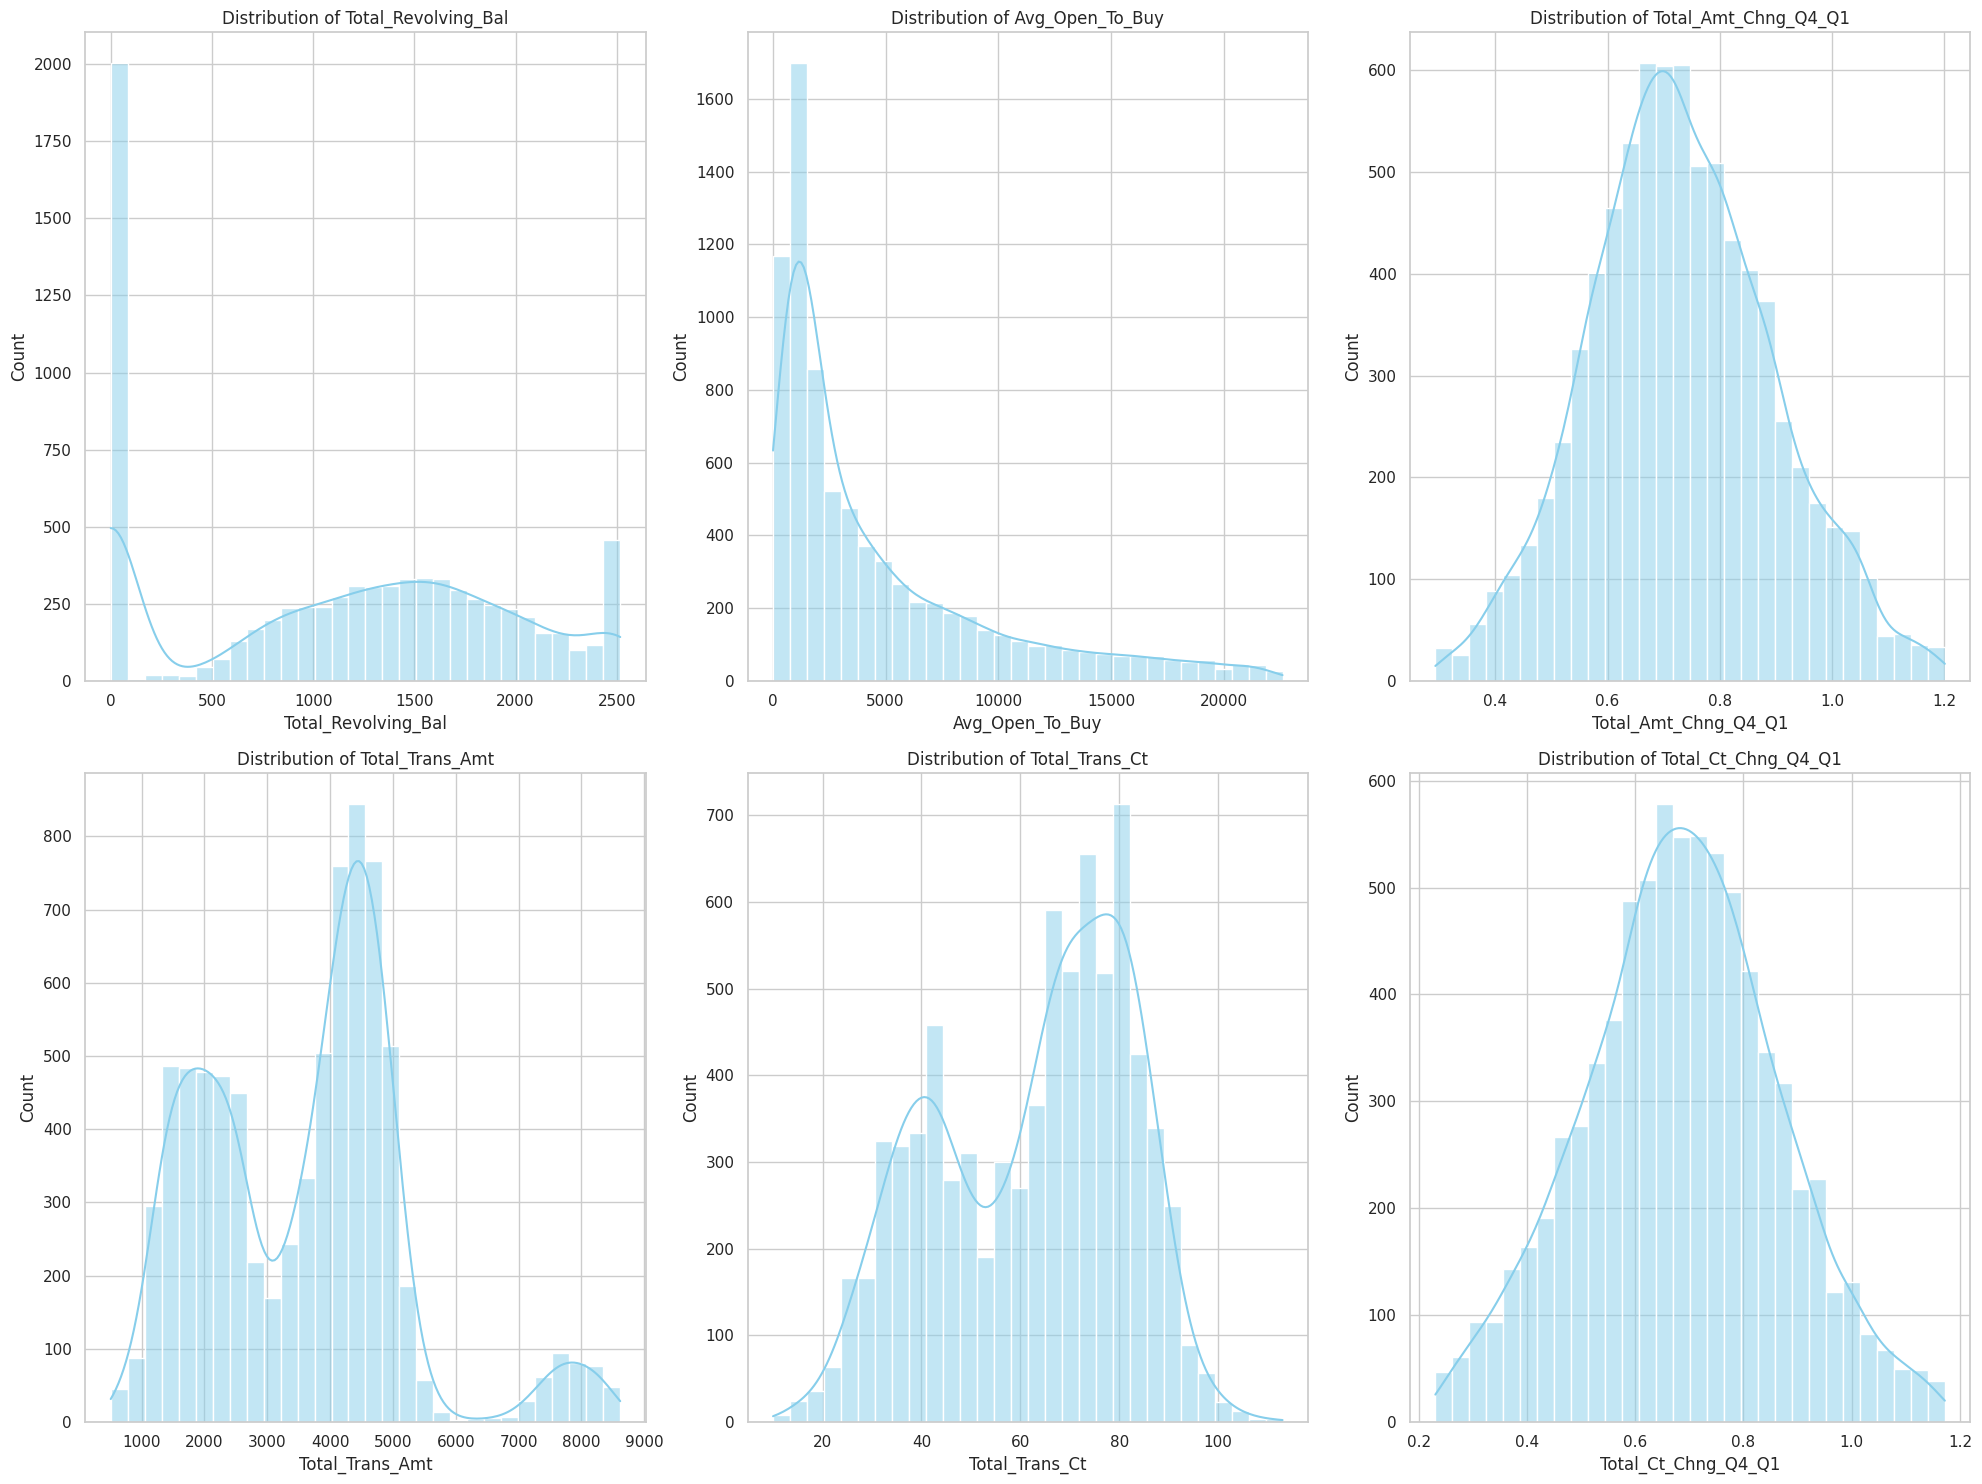

In [27]:
columns = [
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1'
]

# Set plot style
sns.set(style='whitegrid')

# Plot 1: Distribution Plots
plt.figure(figsize=(20, 15))
for i, col in enumerate(columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(data[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

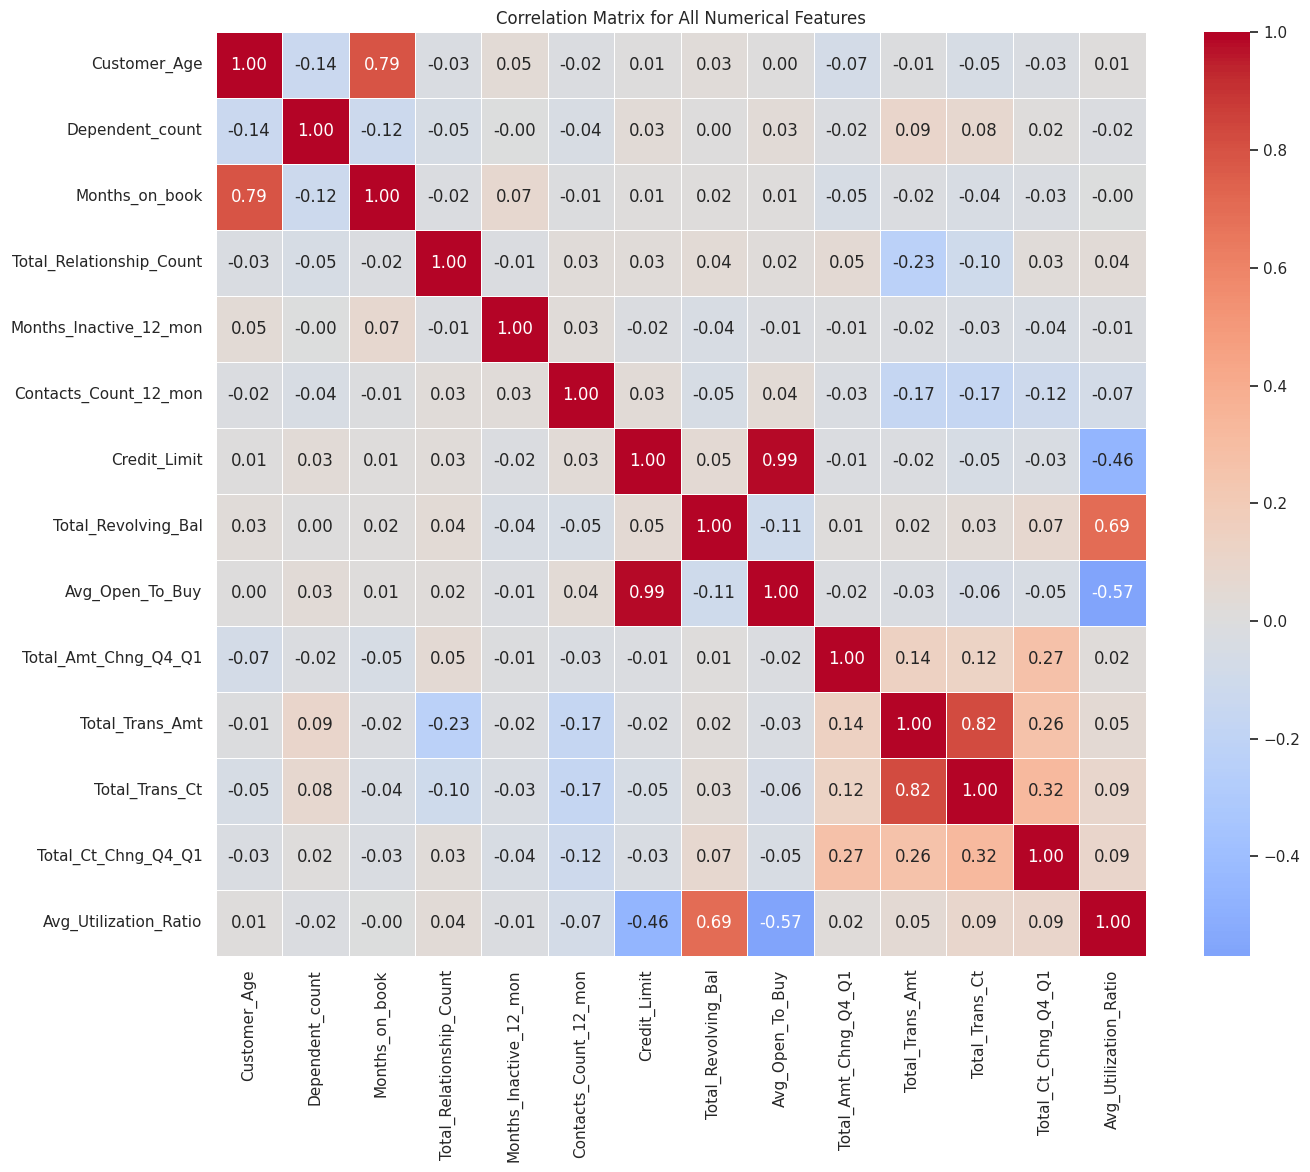

In [28]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = data[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for All Numerical Features')
plt.show()

'Avg_Open_To_Buy' and "Credit_Limit' show very strong correlation. It will be ok to drop Open to buy because credit limit is important to problem

In [29]:
data = data.drop('Avg_Open_To_Buy', axis=1)

## Part 3: Customer Segmentation

### Segmentation Model: Use clustering techniques (e.g., K-Means) to segment the customers based on their credit card usage and demographic data. Determine the optimal number of clusters.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [31]:
data.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Age_Group'],
      dtype='object')

#### One hot encoded categorical varibales and scaled numerical variables for preprocessing before clustering

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

one_hot_cols = [
    "Gender", "Education_Level", "Marital_Status", "Income_Category",
    "Card_Category", "Dependent_count", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Attrition_Flag"
]

numerical_cols = [
    'Customer_Age', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

In [33]:
# One-Hot Encoding for Categorical Variables
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = encoder.fit_transform(data[one_hot_cols])

encoded_col_names = encoder.get_feature_names_out(one_hot_cols)
categorical_encoded_df = pd.DataFrame(categorical_encoded, columns=encoded_col_names)

In [34]:
# Scale Numerical Features
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(data[numerical_cols])
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_cols)

In [35]:
# Combine Encoded Categorical and Scaled Numerical Features
processed_data = pd.concat([categorical_encoded_df, numerical_scaled_df], axis=1)

print(processed_data.head())

   Gender_M  Education_Level_Doctorate  Education_Level_Graduate  \
0       1.0                        0.0                       0.0   
1       0.0                        0.0                       1.0   
2       0.0                        0.0                       1.0   
3       1.0                        1.0                       0.0   
4       0.0                        0.0                       1.0   

   Education_Level_High School  Education_Level_Post-Graduate  \
0                          0.0                            0.0   
1                          0.0                            0.0   
2                          0.0                            0.0   
3                          0.0                            0.0   
4                          0.0                            0.0   

   Education_Level_Uneducated  Education_Level_Unknown  \
0                         1.0                      0.0   
1                         0.0                      0.0   
2                         

#### Choosing optimal number of k using Elbow method and Silhouette Score method

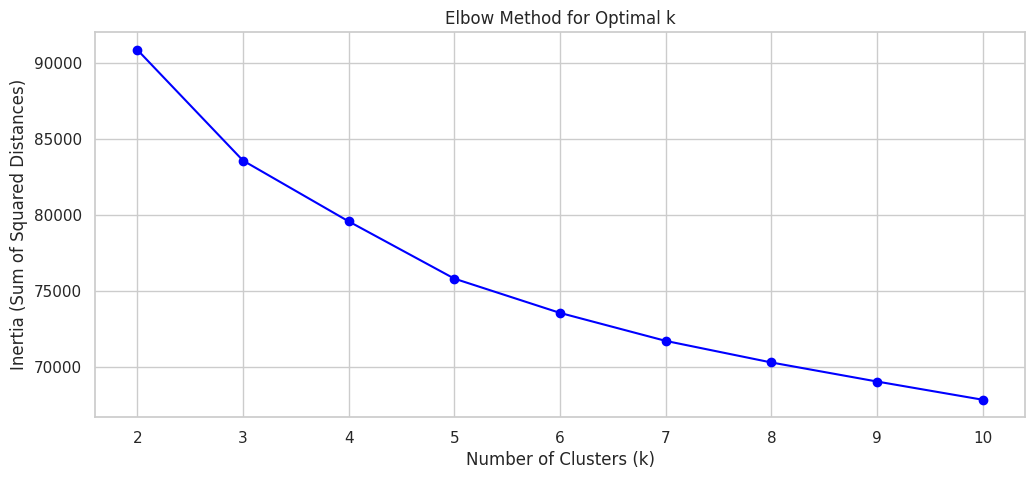

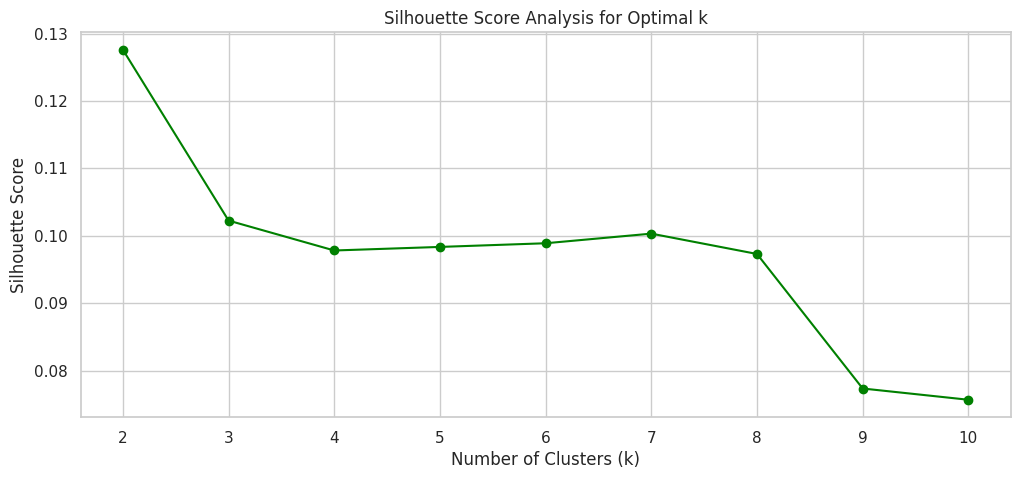

In [36]:
k_values = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(processed_data)
    inertia.append(kmeans.inertia_)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(processed_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Elbow Method Plot
plt.figure(figsize=(12, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# Silhouette Score Plot
plt.figure(figsize=(12, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis for Optimal k')
plt.grid(True)
plt.show()

 Elbow plot not showing optimal number of clusters clearly. Optimal number of k is choosen as 2 because it has the highest silhouette

##### Performing PCA before clustering to reduce dimensionality and use feature which explain most variance

In [37]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(processed_data)

Using 2 components to show visualize in 2D

In [38]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(processed_data)

In [39]:
data_clustered = data.copy()
data_clustered['Cluster'] = clusters
print(data_clustered.head())

       Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
10  Existing Customer            42      M                5      Uneducated   
14  Existing Customer            57      F                2        Graduate   
19  Existing Customer            45      F                2        Graduate   
20  Existing Customer            47      M                1       Doctorate   
21  Attrited Customer            62      F                0        Graduate   

   Marital_Status Income_Category Card_Category  Months_on_book  \
10        Unknown         $120K +          Blue              31   
14        Married  Less than $40K          Blue              48   
19        Married         Unknown          Blue              37   
20       Divorced     $60K - $80K          Blue              42   
21        Married  Less than $40K          Blue              49   

    Total_Relationship_Count  ...  Contacts_Count_12_mon  Credit_Limit  \
10                         5  ...               

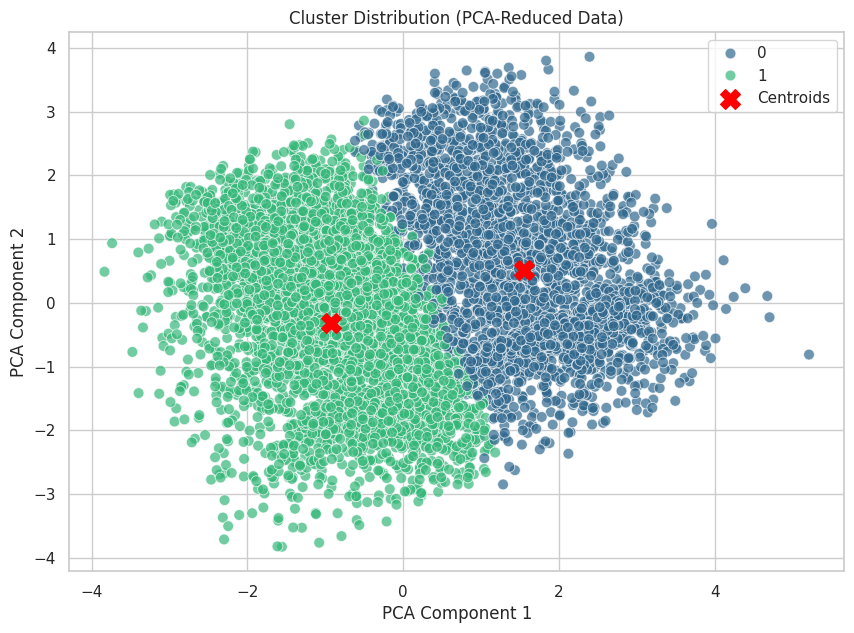

In [40]:
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=60,
    alpha=0.7
)

# Plot centroids
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)  # Transform centroids to PCA space
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroids'
)

# Add labels and title
plt.title('Cluster Distribution (PCA-Reduced Data)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

This plot shows customer clusters in a 2D space derived from PCA, revealing two distinct groups (0 and 1) with different spending behaviors.

In [41]:
print(f"Silhouette score for k=2: {silhouette_scores[0]}")

Silhouette score for k=2: 0.12760979226042213


#### Segment Analysis: Analyze each customer segment to identify unique behaviors and characteristics. Provide actionable insights for targeted marketing strategies.

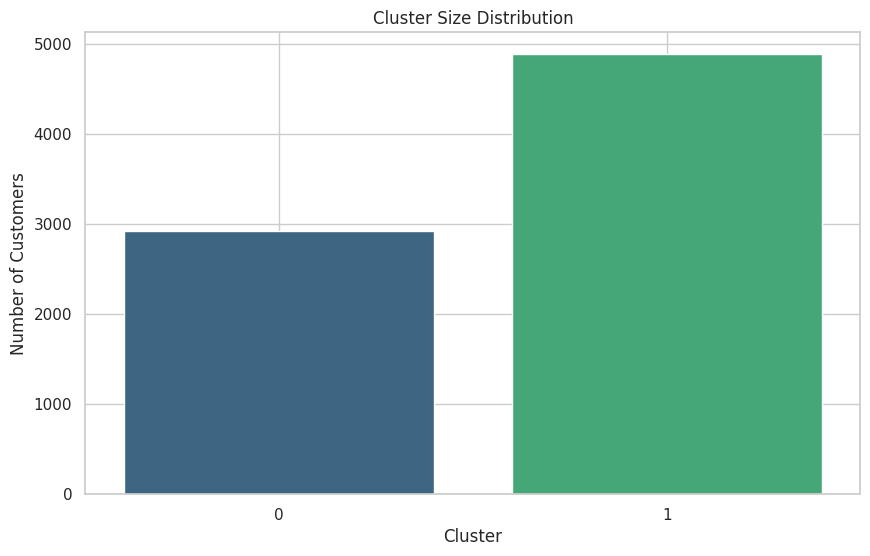

In [42]:
cluster_counts = data_clustered['Cluster'].value_counts().sort_index()

# Plotting Cluster Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

This bar plot shows a relatively balanced distribution of customers across two clusters

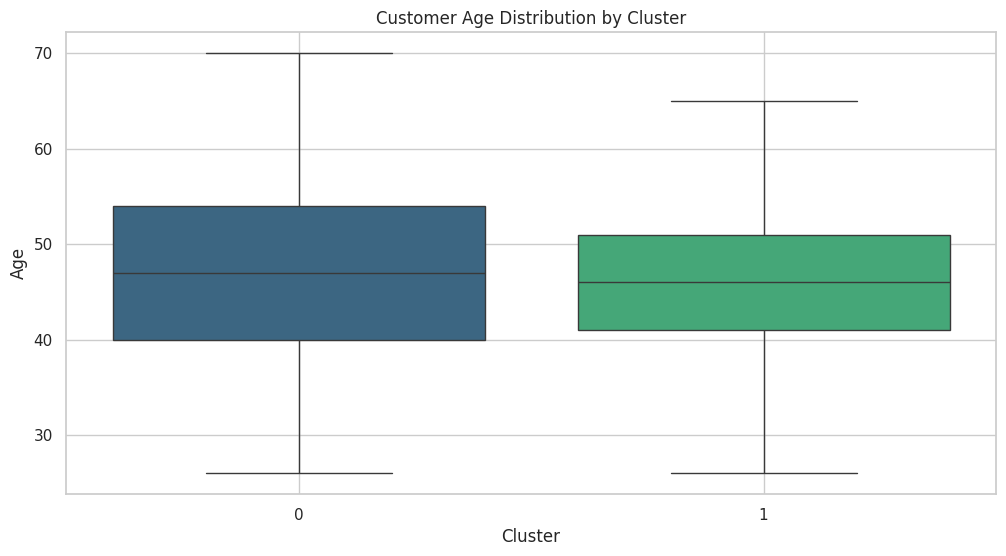

In [43]:
# Age Distribution Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Customer_Age', data=data_clustered, palette='viridis')
plt.title('Customer Age Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.grid(True)
plt.show()

Customer age distribution show both clusters have a similar median age in the mid-40s.

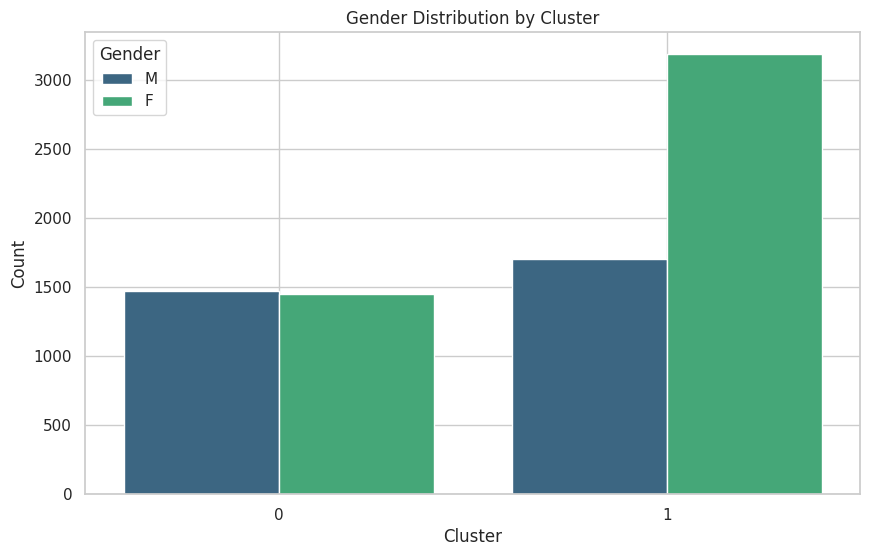

In [44]:
# Gender Distribution by Cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='Gender', data=data_clustered, palette='viridis')
plt.title('Gender Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.grid(True)
plt.show()

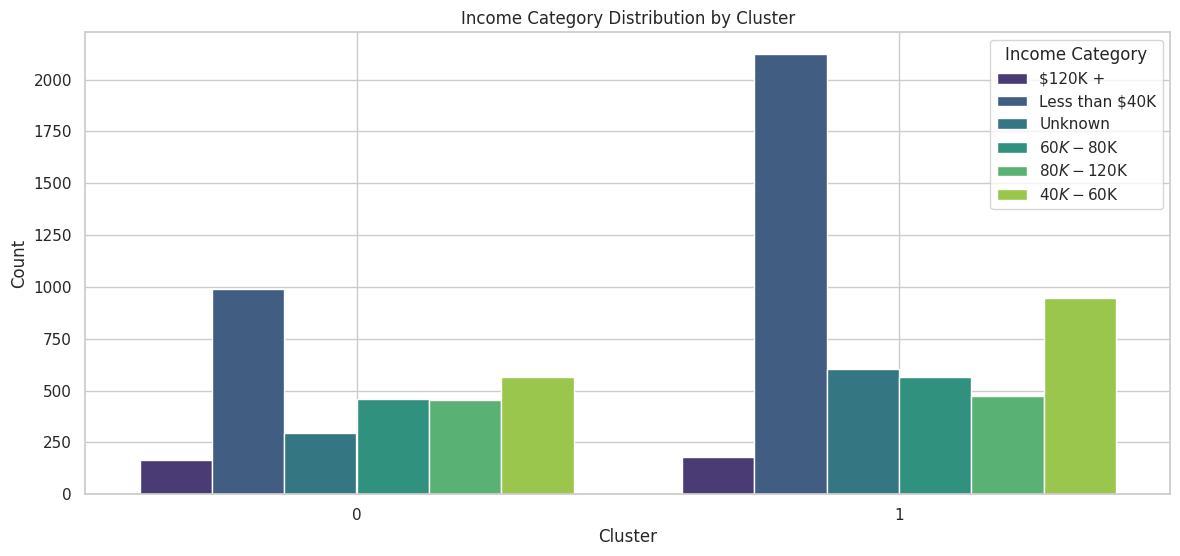

In [45]:
# Income Category Distribution
plt.figure(figsize=(14, 6))
sns.countplot(x='Cluster', hue='Income_Category', data=data_clustered, palette='viridis')
plt.title('Income Category Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Income Category', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

Cluster 1 is predominantly composed of customers in the highest income bracket ($120K+), while Cluster 0 shows a more balanced distribution across income categories.

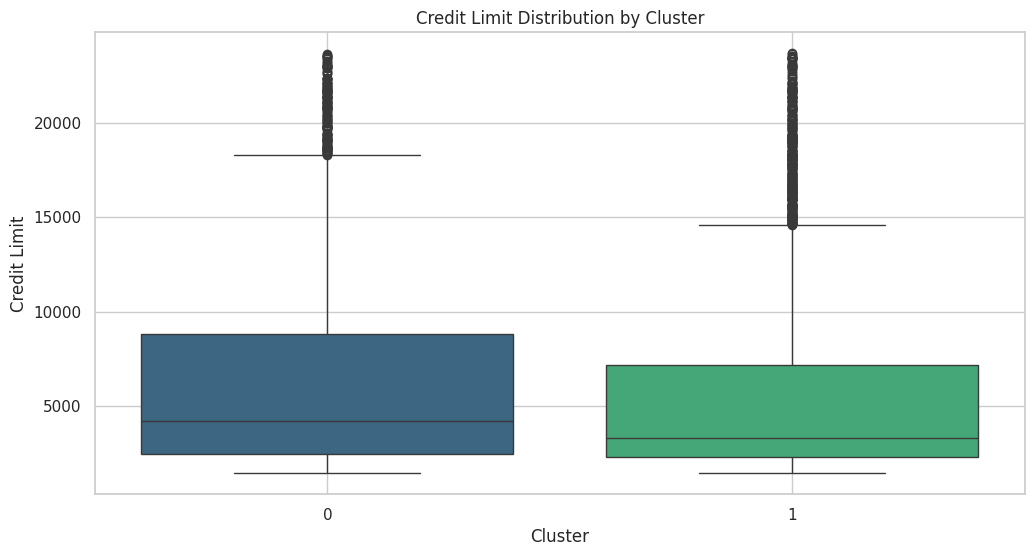

In [46]:
# Credit Limit Distribution by Cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Credit_Limit', data=data_clustered, palette='viridis')
plt.title('Credit Limit Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Credit Limit')
plt.grid(True)
plt.show()


Cluster 0 exhibits a significantly higher median credit limit and a wider range of credit limits compared to Cluster 1, indicating that Cluster 0 represents customers with substantially greater credit lines.

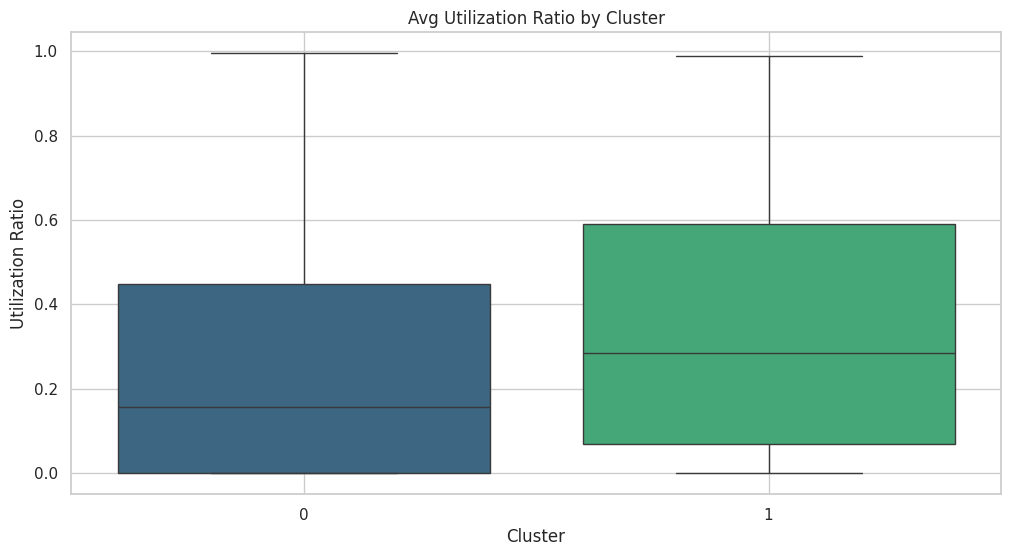

In [47]:
# Average Utilization Ratio by Cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Avg_Utilization_Ratio', data=data_clustered, palette='viridis')
plt.title('Avg Utilization Ratio by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Utilization Ratio')
plt.grid(True)
plt.show()

Cluster 1 demonstrates a much higher average utilization ratio with a wider spread compared to Cluster 0, implying that customers in Cluster 1 are using a larger proportion of their available credit.

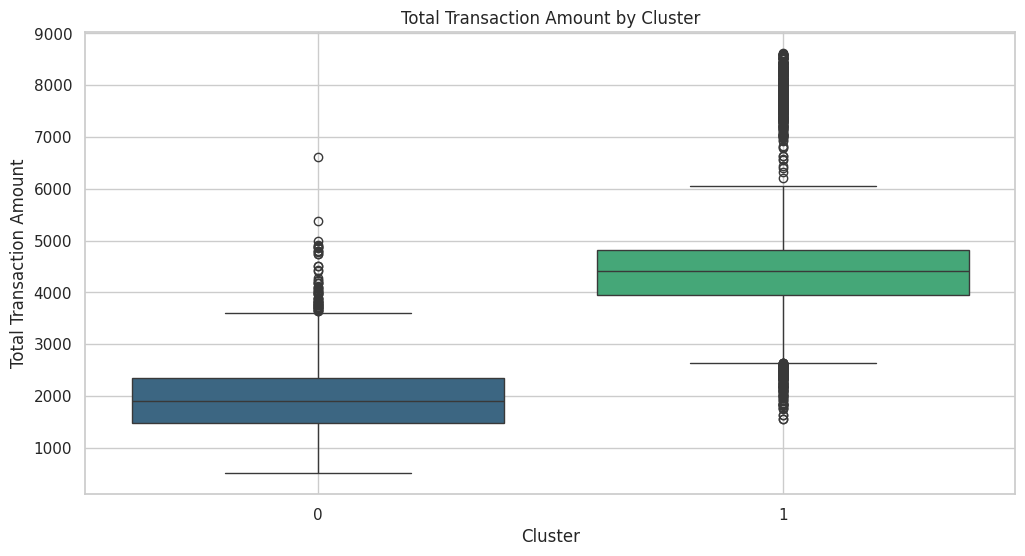

In [48]:
# Total Transaction Amount Distribution by Cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Total_Trans_Amt', data=data_clustered, palette='viridis')
plt.title('Total Transaction Amount by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Transaction Amount')
plt.grid(True)
plt.show()


Both Clusters exhibits a higher median total transaction amount and a wider range of transaction .

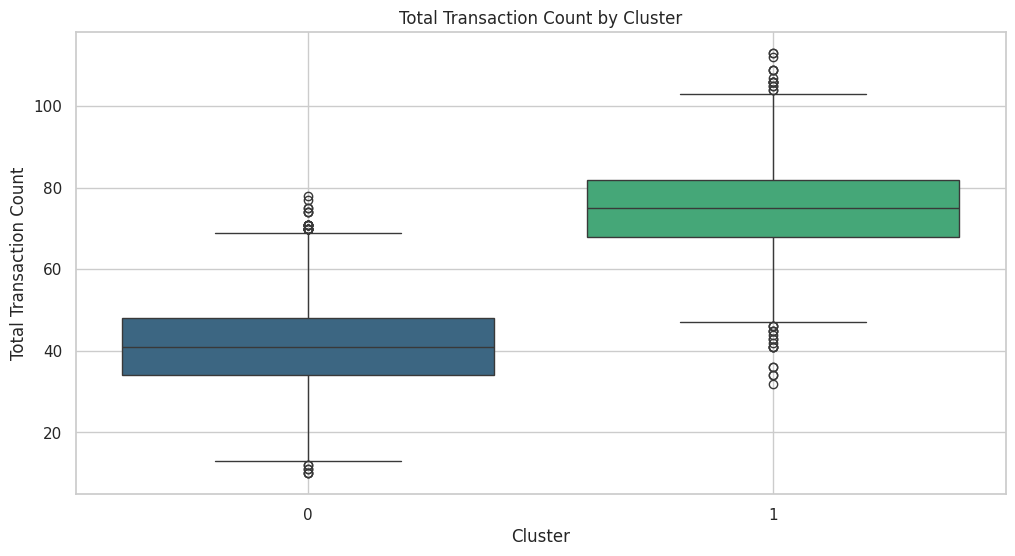

In [49]:
# Total Transaction Count by Cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Total_Trans_Ct', data=data_clustered, palette='viridis')
plt.title('Total Transaction Count by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Transaction Count')
plt.grid(True)
plt.show()


Cluster 1 tends to have slightly higher total transaction counts and a wider range of transaction counts compared to Cluster 0, suggesting more frequent transactions on average.


**Cluster 0: Seeking for Value Customers**

Predominantly female, with lower credit limits and higher utilization ratios.

Likely to be price-sensitive and reliant on credit for daily expenses.

Marketing Strategy: Value-driven offers, financial literacy programs, and digital engagement.

**Cluster 1: Established Spenders**

Higher credit limits, lower utilization ratios, and more frequent transactions.

Secure customers with diverse spending patterns.

Marketing Strategy: Premium rewards, personalized offers, and credit management.

## Part 4: Predictive Modeling

### Churn Prediction: Build a predictive model to forecast customer churn based on the features available in the dataset. Experiment with at least two different algorithms and compare their performance.

In [50]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

In [51]:
data_m = data.copy()

#### Label Encoding categorical variables and assigning 1 for churn and 0 not churn customers

In [52]:
# Encode Categorical Variables
label_encoders = {}
categorical_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Encode Target Variable
data['Attrition_Flag'] = data['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

In [53]:
X = data.drop(['Age_Group', 'Attrition_Flag'], axis=1)
y = data['Attrition_Flag']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Numerical Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
print(data['Attrition_Flag'].value_counts())

Attrition_Flag
0    6514
1    1300
Name: count, dtype: int64


In [55]:
# Address Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Using SMOTE to Handle Class Imbalance in Target Variable

In [56]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n{model_name} Performance Metrics:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

##### Training and testing on different Models

###### On Original Data


Random Forest (Original Data) Performance Metrics:
Accuracy: 0.9597
Precision: 0.9498
Recall: 0.8000
F1-Score: 0.8685
ROC-AUC Score: 0.9882

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1303
           1       0.95      0.80      0.87       260

    accuracy                           0.96      1563
   macro avg       0.96      0.90      0.92      1563
weighted avg       0.96      0.96      0.96      1563



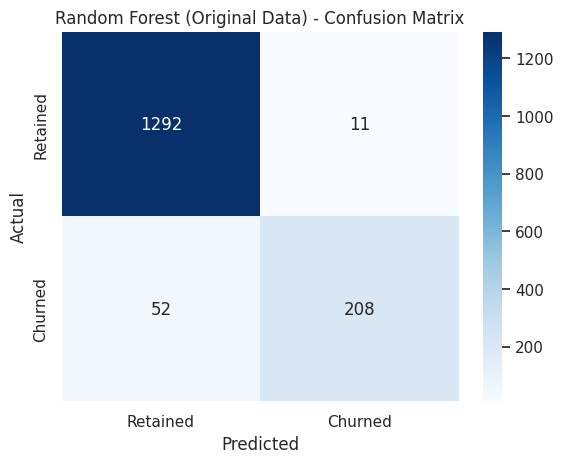

In [57]:
# Model 1: Random Forest on Original Data
rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train, y_train)
y_pred_rf_orig = rf_original.predict(X_test)
y_prob_rf_orig = rf_original.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rf_orig, y_prob_rf_orig, "Random Forest (Original Data)")


XGBoost (Original Data) Performance Metrics:
Accuracy: 0.9693
Precision: 0.9454
Recall: 0.8654
F1-Score: 0.9036
ROC-AUC Score: 0.9910

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1303
           1       0.95      0.87      0.90       260

    accuracy                           0.97      1563
   macro avg       0.96      0.93      0.94      1563
weighted avg       0.97      0.97      0.97      1563



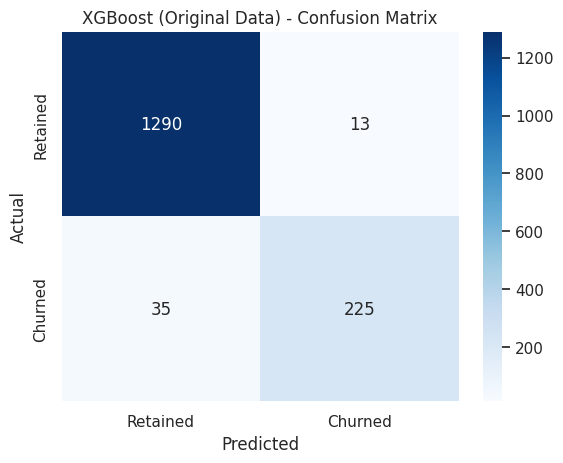

In [58]:
# Model 2: XGBoost on Original Data
xgb_original = XGBClassifier(random_state=42)
xgb_original.fit(X_train, y_train)
y_pred_xgb_orig = xgb_original.predict(X_test)
y_prob_xgb_orig = xgb_original.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_xgb_orig, y_prob_xgb_orig, "XGBoost (Original Data)")

###### On SMOTE Data


Random Forest (SMOTE Data) Performance Metrics:
Accuracy: 0.9533
Precision: 0.8725
Recall: 0.8423
F1-Score: 0.8571
ROC-AUC Score: 0.9866

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1303
           1       0.87      0.84      0.86       260

    accuracy                           0.95      1563
   macro avg       0.92      0.91      0.91      1563
weighted avg       0.95      0.95      0.95      1563



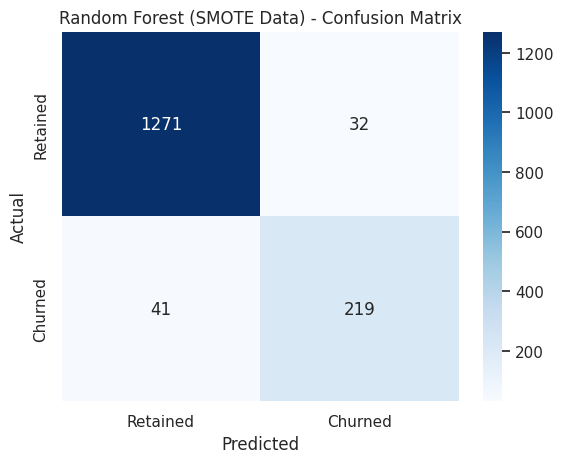

In [59]:
# Model 3: Random Forest on SMOTE Data
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)
y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rf_smote, y_prob_rf_smote, "Random Forest (SMOTE Data)")


XGBoost (SMOTE Data) Performance Metrics:
Accuracy: 0.9674
Precision: 0.9300
Recall: 0.8692
F1-Score: 0.8986
ROC-AUC Score: 0.9893

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1303
           1       0.93      0.87      0.90       260

    accuracy                           0.97      1563
   macro avg       0.95      0.93      0.94      1563
weighted avg       0.97      0.97      0.97      1563



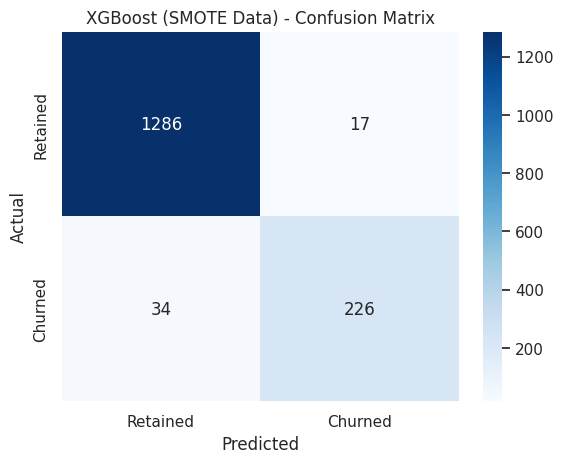

In [60]:
# Model 4: XGBoost on SMOTE Data
xgb_smote = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_xgb_smote, y_prob_xgb_smote, "XGBoost (SMOTE Data)")

###### Balanced Random Forest on Original Data


Balanced Random Forest (Original Data) Performance Metrics:
Accuracy: 0.9501
Precision: 0.8204
Recall: 0.8962
F1-Score: 0.8566
ROC-AUC Score: 0.9859

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1303
           1       0.82      0.90      0.86       260

    accuracy                           0.95      1563
   macro avg       0.90      0.93      0.91      1563
weighted avg       0.95      0.95      0.95      1563



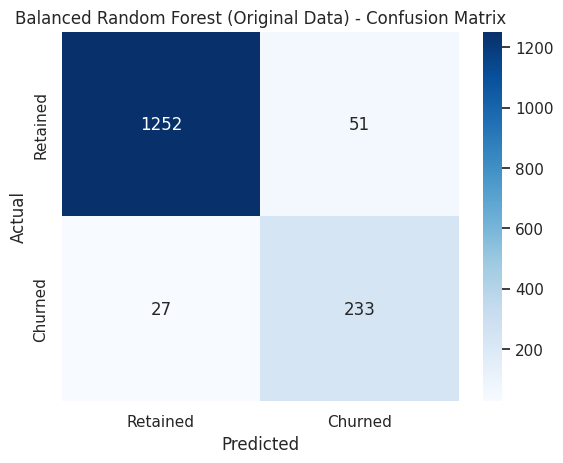

In [61]:
# Model 5: Balanced Random Forest on Original Data
brf_original = BalancedRandomForestClassifier(random_state=42)
brf_original.fit(X_train, y_train)
y_pred_brf_orig = brf_original.predict(X_test)
y_prob_brf_orig = brf_original.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_brf_orig, y_prob_brf_orig, "Balanced Random Forest (Original Data)")

Working same as Random Forest but handles Class Imbalance automatically

###### Cross Validating on SMOTE Data

In [62]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [63]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation: Random Forest on SMOTE Data
cv_rf_smote = cross_val_score(rf_smote, X_train_smote, y_train_smote, cv=cv, scoring='f1')
print("\nRandom Forest (SMOTE Data) Cross-Validation F1 Scores:", cv_rf_smote)
print("Mean F1-Score:", np.mean(cv_rf_smote))


Random Forest (SMOTE Data) Cross-Validation F1 Scores: [0.97521449 0.97845859 0.97805344 0.97665555 0.97803247]
Mean F1-Score: 0.9772829083459064


In [64]:
# Cross Validation: XGBoost on SMOTE Data
cv_xgb_smote = cross_val_score(xgb_smote, X_train_smote, y_train_smote, cv=cv, scoring='f1')
print("\nXGBoost (SMOTE Data) Cross-Validation F1 Scores:", cv_xgb_smote)
print("Mean F1-Score:", np.mean(cv_xgb_smote))


XGBoost (SMOTE Data) Cross-Validation F1 Scores: [0.97939626 0.98277512 0.98272553 0.98228818 0.97799043]
Mean F1-Score: 0.9810351033618068


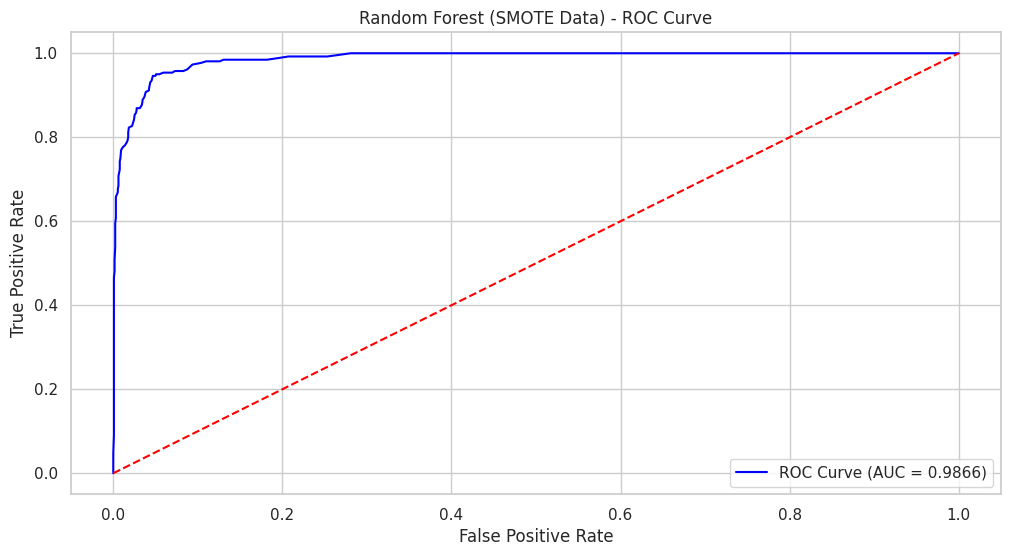

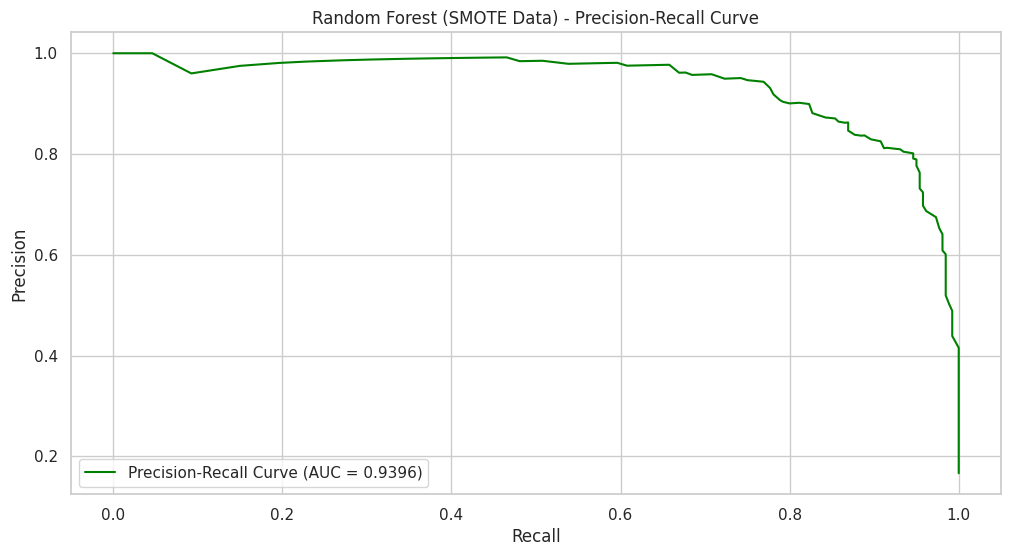

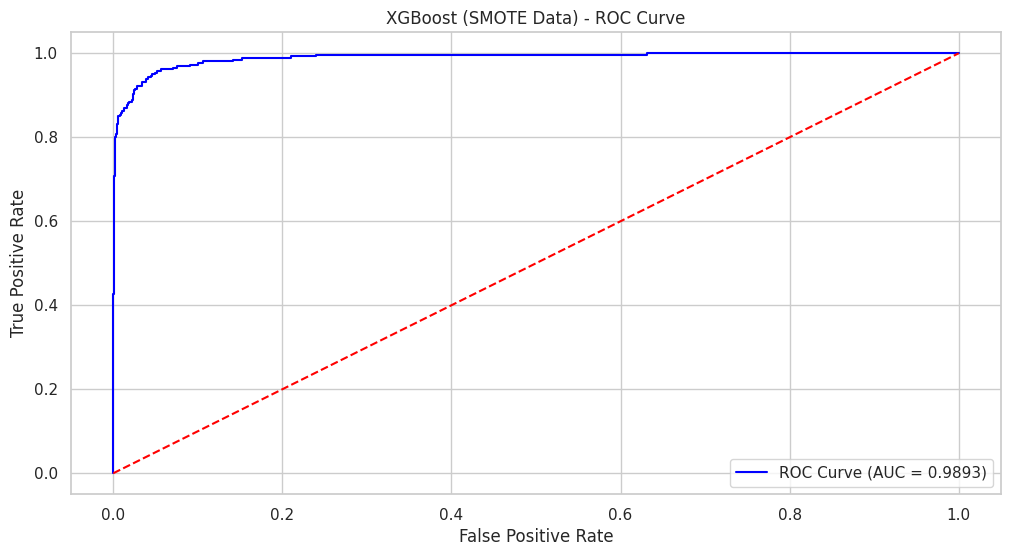

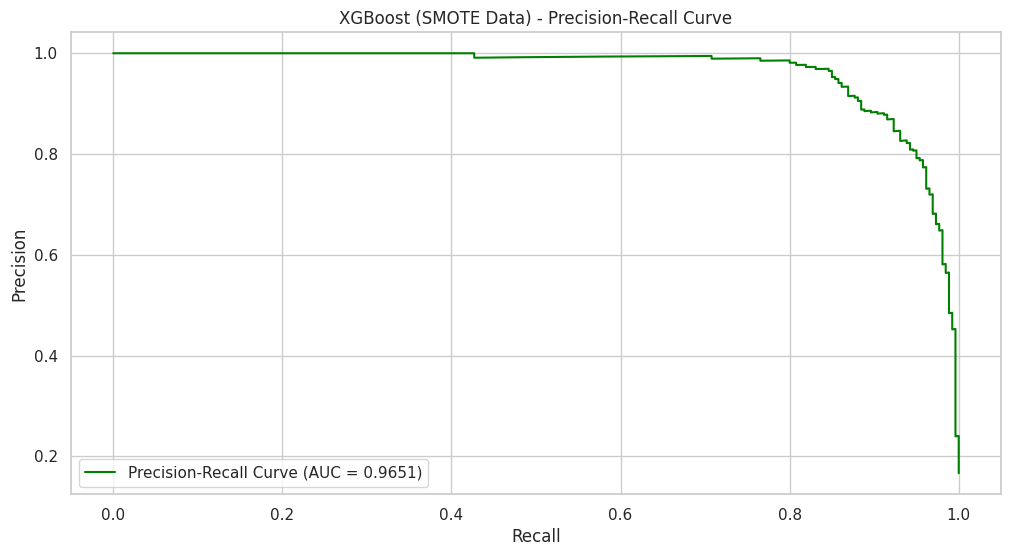

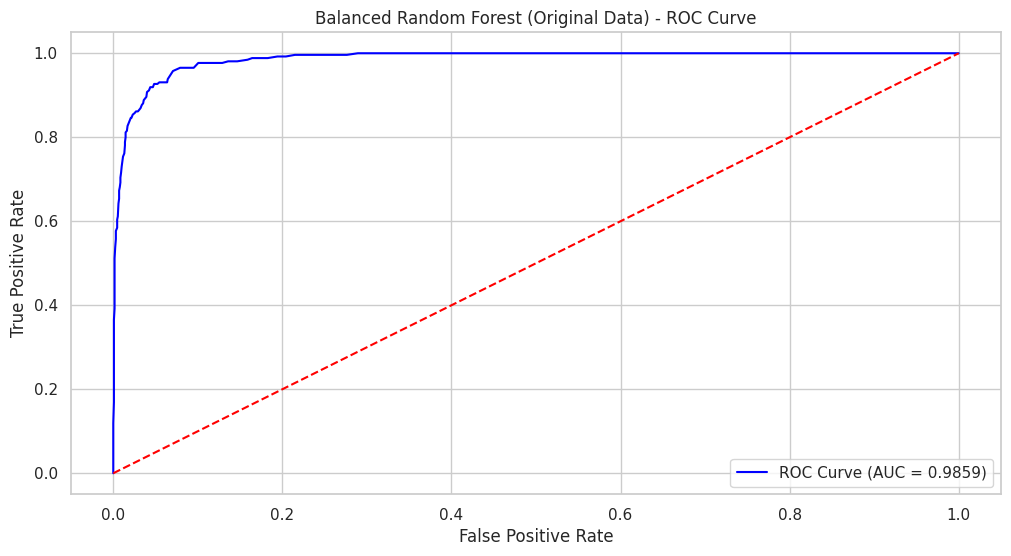

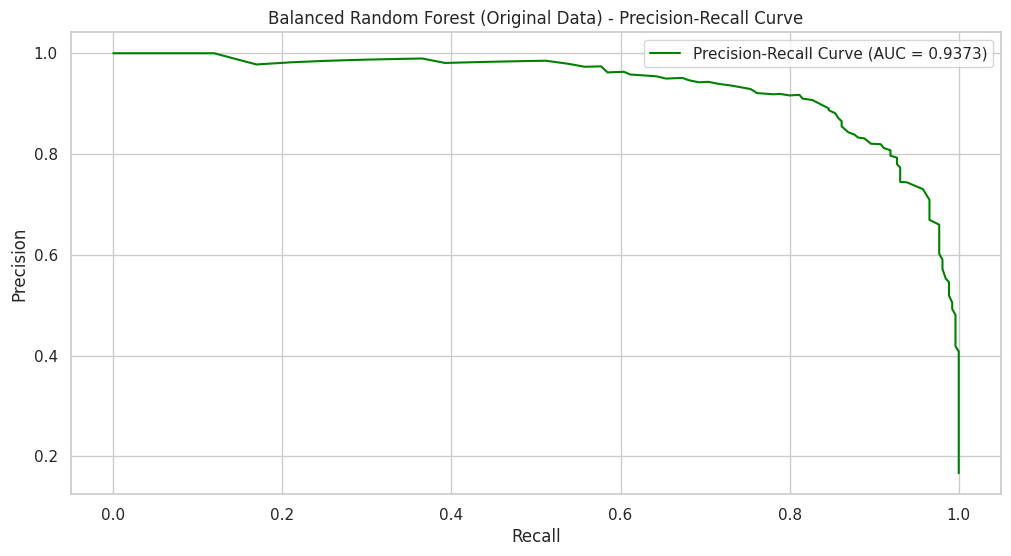

In [65]:
def plot_curves(y_true, y_prob, model_name):
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(12, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Precision-Recall Curve
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(12, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
    plt.title(f'{model_name} - Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting Curves for Models on SMOTE Data
plot_curves(y_test, y_prob_rf_smote, "Random Forest (SMOTE Data)")
plot_curves(y_test, y_prob_xgb_smote, "XGBoost (SMOTE Data)")

# Plotting Curves for Balanced Random Forest on Original Data
plot_curves(y_test, y_prob_brf_orig, "Balanced Random Forest (Original Data)")

The models demonstrate good performances in classifying customers and all effectively handling potential class imbalance either through SMOTE or model design.

### Model Evaluation: Assess the models using appropriate performance metrics. Discuss the strengths and weaknesses of each model.

In [66]:
# Calculate Metrics for Balanced Random Forest on Original Data
brf_acc = accuracy_score(y_test, y_pred_brf_orig)
brf_prec = precision_score(y_test, y_pred_brf_orig)
brf_rec = recall_score(y_test, y_pred_brf_orig)
brf_f1 = f1_score(y_test, y_pred_brf_orig)
brf_auc = roc_auc_score(y_test, y_prob_brf_orig)

# Calculate Metrics for Random Forest on SMOTE Data
rf_acc = accuracy_score(y_test, y_pred_rf_smote)
rf_prec = precision_score(y_test, y_pred_rf_smote)
rf_rec = recall_score(y_test, y_pred_rf_smote)
rf_f1 = f1_score(y_test, y_pred_rf_smote)
rf_auc = roc_auc_score(y_test, y_prob_rf_smote)

# Calculate Metrics for XGBoost on SMOTE Data
xgb_acc = accuracy_score(y_test, y_pred_xgb_smote)
xgb_prec = precision_score(y_test, y_pred_xgb_smote)
xgb_rec = recall_score(y_test, y_pred_xgb_smote)
xgb_f1 = f1_score(y_test, y_pred_xgb_smote)
xgb_auc = roc_auc_score(y_test, y_prob_xgb_smote)

# Calculate Metrics for Random Forest on Original Data
rf_acc_orig = accuracy_score(y_test, y_pred_rf_orig)
rf_prec_orig = precision_score(y_test, y_pred_rf_orig)
rf_rec_orig = recall_score(y_test, y_pred_rf_orig)
rf_f1_orig = f1_score(y_test, y_pred_rf_orig)
rf_auc_orig = roc_auc_score(y_test, y_prob_rf_orig)

# Calculate Metrics for XGBoost on Original Data
xgb_acc_orig = accuracy_score(y_test, y_pred_xgb_orig)
xgb_prec_orig = precision_score(y_test, y_pred_xgb_orig)
xgb_rec_orig = recall_score(y_test, y_pred_xgb_orig)
xgb_f1_orig = f1_score(y_test, y_pred_xgb_orig)
xgb_auc_orig = roc_auc_score(y_test, y_prob_xgb_orig)

In [67]:
model_comparison = pd.DataFrame({
    'Model': ['Balanced RF (Original)', 'Random Forest (Original)', 'Random Forest (SMOTE)', 'XGBoost (Original)', 'XGBoost (SMOTE)'],
    'Accuracy': [brf_acc, rf_acc_orig, rf_acc, xgb_acc_orig, xgb_acc],
    'Precision': [brf_prec, rf_prec_orig, rf_prec, xgb_prec_orig, xgb_prec],
    'Recall': [brf_rec, rf_rec_orig, rf_rec, xgb_rec_orig, xgb_rec],
    'F1-Score': [brf_f1, rf_f1_orig, rf_f1, xgb_f1_orig, xgb_f1],
    'ROC-AUC': [brf_auc, rf_auc_orig, rf_auc, xgb_auc_orig, xgb_auc]
})

# Display the Comparison Table
print("\nModel Comparison:")
print(model_comparison.sort_values(by='F1-Score', ascending=False).reset_index(drop=True))


Model Comparison:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0        XGBoost (Original)  0.969290   0.945378  0.865385  0.903614  0.990985
1           XGBoost (SMOTE)  0.967370   0.930041  0.869231  0.898608  0.989326
2  Random Forest (Original)  0.959693   0.949772  0.800000  0.868476  0.988231
3     Random Forest (SMOTE)  0.953295   0.872510  0.842308  0.857143  0.986575
4    Balanced RF (Original)  0.950096   0.820423  0.896154  0.856618  0.985867


In [68]:
best_model = model_comparison.loc[model_comparison['F1-Score'].idxmax()]

print("\nBest Model Based on F1-Score:")
print(best_model)


Best Model Based on F1-Score:
Model        XGBoost (Original)
Accuracy                0.96929
Precision              0.945378
Recall                 0.865385
F1-Score               0.903614
ROC-AUC                0.990985
Name: 3, dtype: object


XGBoost showed the best performance with good F1 Score of 90%

##### Strengths and Weakness of each model


Random Forest:

Strengths: Versatile, easy to use, handles both classification and regression, can capture non-linear relationships, relatively fast training.

Weaknesses: Can be less accurate than boosting methods like XGBoost, can sometimes oversimplify complex relationships.


XGBoost:

Strengths: High accuracy, handles missing data well, regularization to prevent overfitting, fast gradient boosting implementation, good for complex datasets.

Weaknesses: More computationally intensive and slower to train than Random Forest, can be prone to overfitting if not tuned properly.


Balanced Random Forest:

Strengths: Specifically designed for imbalanced datasets, handles both classification and regression, can be more efficient than oversampling/undersampling techniques.

Weaknesses: May not achieve the absolute highest accuracy compared to other methods.